In [ ]:
import pandas as pd
import time
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
t0 = time.perf_counter()

df = pd.read_csv("../data/raw/paysim.csv")

t1 = time.perf_counter()

print("Data loaded")
print(f"Read CSV: {t1-t0:.2f}s")

Data loaded
Read CSV: 10.55s


Data description Kaggle:

step - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

amount - amount of the transaction in local currency.

nameOrig - customer who started the transaction

oldbalanceOrg - initial balance before the transaction

newbalanceOrig - new balance after the transaction.

nameDest - customer who is the recipient of the transaction

oldbalanceDest - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

newbalanceDest - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

isFlaggedFraud - The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

In [3]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [4]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

From "PAYSIM: A FINANCIAL MOBILE MONEY SIMULATOR FOR FRAUD DETECTION":

CASH-IN is the process of increasing the balance of account by paying in cash to a merchant.
CASH-OUT is the opposite process of CASH-IN, it means to withdraw cash from a merchant which decreases the balance of the account.
DEBIT is similar process than CASH-OUT and involves sending the money from the mobile money service to a bank account.
PAYMENT is the process of paying for goods or services to merchants which decreases the balance of the account and increases the balance of the receiver.
TRANSFER is the process of sending money to another user of the service through the mobile money platform

In [5]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [6]:
sum(df['isFlaggedFraud'])/len(df['isFlaggedFraud'])

2.51468734577894e-06

In [7]:
df_flagged_fraud = df[df['isFlaggedFraud'] == 1]
df_flagged_fraud.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2736446,212,TRANSFER,4953893.08,C728984460,4953893.08,4953893.08,C639921569,0.0,0.0,1,1
3247297,250,TRANSFER,1343002.08,C1100582606,1343002.08,1343002.08,C1147517658,0.0,0.0,1,1
3760288,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.0,0.0,1,1
5563713,387,TRANSFER,4892193.09,C908544136,4892193.09,4892193.09,C891140444,0.0,0.0,1,1
5996407,425,TRANSFER,10000000.00,C689608084,19585040.37,19585040.37,C1392803603,0.0,0.0,1,1


In [8]:
df_flagged_fraud.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,16.000000,1.600000e+01,1.600000e+01,1.600000e+01,16.0,16.0,16.0,16.0
mean,537.562500,4.861598e+06,7.817869e+06,7.817869e+06,0.0,0.0,1.0,1.0
std,181.895196,3.572499e+06,6.972669e+06,6.972669e+06,0.0,0.0,0.0,0.0
min,212.000000,3.538742e+05,3.538742e+05,3.538742e+05,0.0,0.0,1.0,1.0
25%,415.500000,2.242749e+06,3.013980e+06,3.013980e+06,0.0,0.0,1.0,1.0
50%,601.500000,4.234245e+06,4.923043e+06,4.923043e+06,0.0,0.0,1.0,1.0
75%,678.750000,7.883451e+06,1.212835e+07,1.212835e+07,0.0,0.0,1.0,1.0
max,741.000000,1.000000e+07,1.958504e+07,1.958504e+07,0.0,0.0,1.0,1.0


In [9]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [10]:
sum(df.duplicated())

0

In [12]:
key_cols = ['step', 'type', 'amount', 'nameOrig', 'nameDest']

n_dup_keys = df.duplicated(subset=key_cols).sum()
print("Duplicate rows by key columns:", n_dup_keys)

Duplicate rows by key columns: 0


In [13]:
df['type'].value_counts(normalize=True)

type
CASH_OUT    0.351663
PAYMENT     0.338146
CASH_IN     0.219923
TRANSFER    0.083756
DEBIT       0.006512
Name: proportion, dtype: float64

In [14]:
nr_nameorig = df['nameOrig'].nunique()
nr_namedest = df['nameDest'].nunique()
nr_names = pd.concat([df['nameOrig'], df['nameDest']]).nunique()

print(f"Unique nameOrig: {nr_nameorig:.0f}")
print(f"Unique nameDest: {nr_namedest:.0f}")
print(f"Unique names: {nr_names:.0f}")

Unique nameOrig: 6353307
Unique nameDest: 2722362
Unique names: 9073900


In [15]:
nr_nameorig + nr_namedest - nr_names

1769

Key takeaways:
- 6,362,620 transactions
- span 743 hours ~ 31 days ~ 1 month
- time is abstracted away, could try to add 24h cycle variables, weekday or cluster-derived variables
- fraudulent transactions constitute 0.13% of all transactions - highly unbalanced dataset, measures other than accuracy need to be used for evaluation
- variable types are: time ('step'), numeric ('amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'), categorical ('type'), IDs ('nameOrig', 'nameDest') and Boolean ('isFlaggedFraud')
- there are no missing values
- there are no duplicates - both exact and taking into account key columns ('step', 'amount', 'nameOrig', 'nameDest')
- most transaction types are (in order of appearance): cash out, payment, cash in, suggesting that the payment system is used mostly for cash needs and purchases rather than to transfer amounts between individuals or interact with the banking system (debit)
- nameOrig and nameDest have high cardinality, won't use in the baseline model, might use some derived features
- most transactions have unique origin names, not much promise for aggregate customer-based features
- destination names repeat, there is a possibility to derive some aggregate features based on transaction destination
- there is not much overlap between origin and destination names, not many transfers between customers

## Feature distributions - for selected features

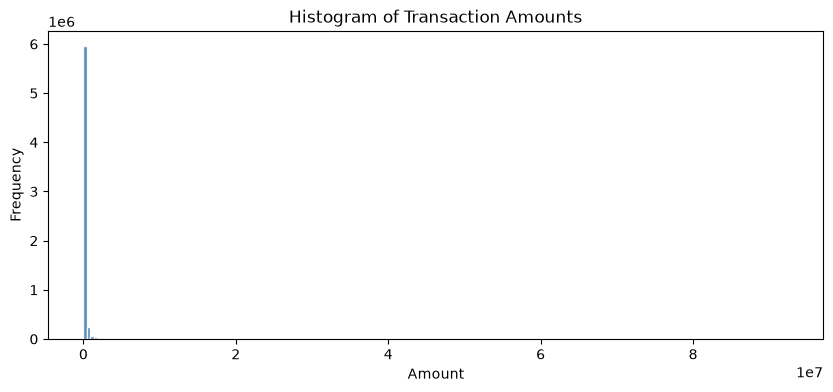

In [16]:
plt.figure(figsize=(10, 4))
plt.hist(df['amount'], bins=200, color='steelblue', edgecolor='white', alpha=0.9)
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.title('Histogram of Transaction Amounts')
plt.show()

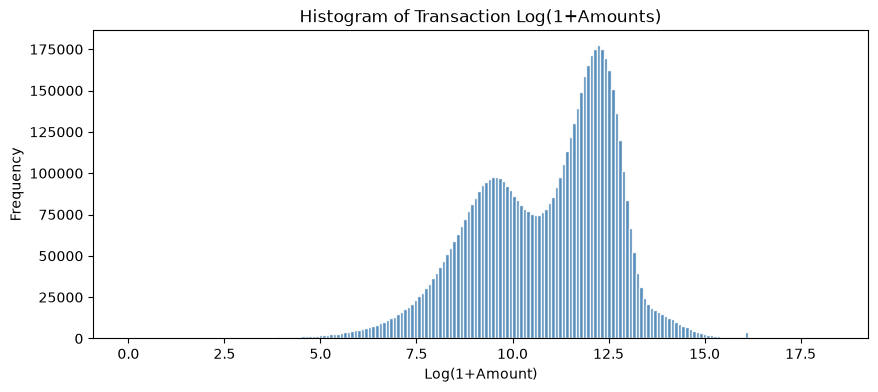

In [51]:
df['log1p_amount'] = np.log1p(df['amount'])

plt.figure(figsize=(10, 4))
plt.hist(df['log1p_amount'], bins=200, color='steelblue', edgecolor='white', alpha=0.9)
plt.xlabel('Log(1+Amount)')
plt.ylabel('Frequency')
plt.title('Histogram of Transaction Log(1+Amounts)')
plt.show()

In [58]:
[np.exp(9.5)-1, np.exp(12.5)-1, np.exp(7.5)-1, np.exp(13.5)-1]

[np.float64(13358.726829661873),
 np.float64(268336.2865208745),
 np.float64(1807.0424144560632),
 np.float64(729415.3698477013)]

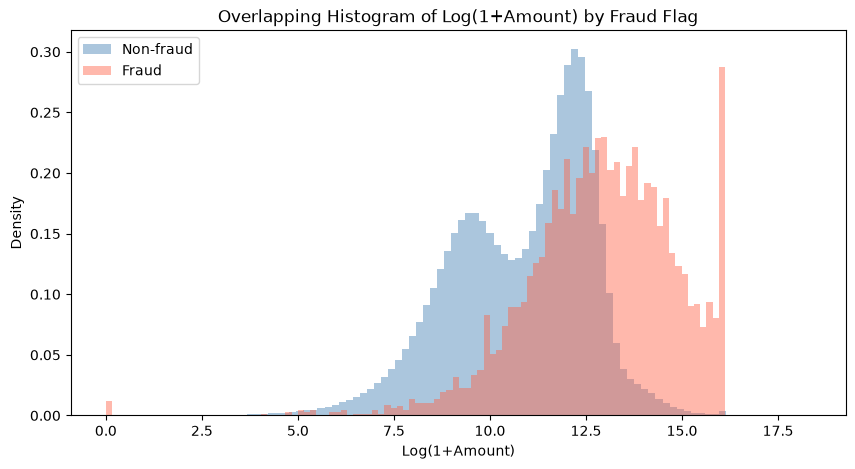

In [55]:
plt.figure(figsize=(10, 5))

amount_nonfraud = df.loc[df['isFraud'] == 0, 'log1p_amount']
amount_fraud = df.loc[df['isFraud'] == 1, 'log1p_amount']

plt.hist(amount_nonfraud, bins=100, alpha=0.45, density=True, label='Non-fraud', color='steelblue')
plt.hist(amount_fraud, bins=100, alpha=0.45, density=True, label='Fraud', color='tomato')

plt.xlabel('Log(1+Amount)')
plt.ylabel('Density')
plt.title('Overlapping Histogram of Log(1+Amount) by Fraud Flag')
plt.legend()
plt.show()

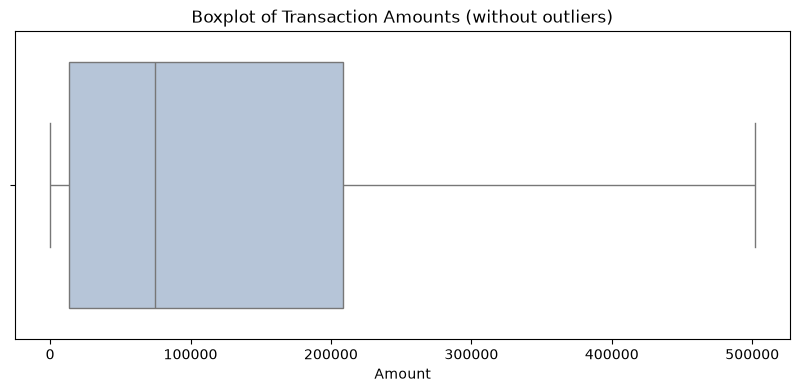

In [19]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['amount'], showfliers=False, color='lightsteelblue')
plt.xlabel('Amount')
plt.title('Boxplot of Transaction Amounts (without outliers)')
plt.show()

In [ ]:
np.percentile(df['amount'], [25, 50, 75])

array([ 13389.57  ,  74871.94  , 208721.4775])

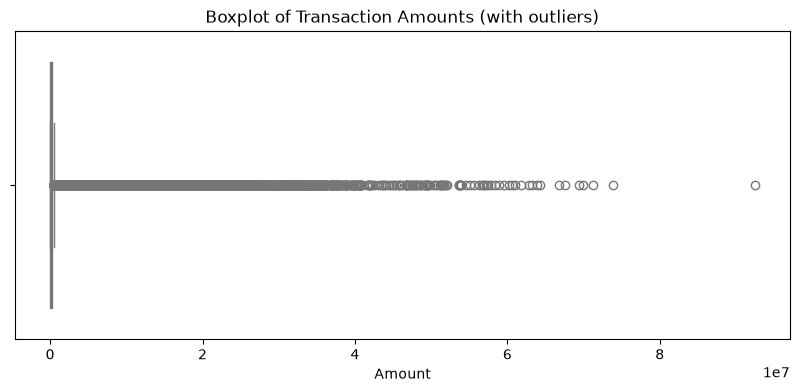

In [20]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['amount'], showfliers=True, color='lightsteelblue')
plt.xlabel('Amount')
plt.title('Boxplot of Transaction Amounts (with outliers)')
plt.show()

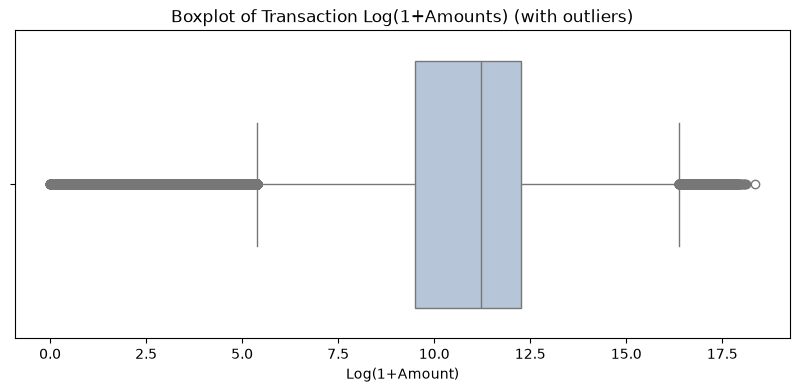

In [52]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['log1p_amount'], showfliers=True, color='lightsteelblue')
plt.xlabel('Log(1+Amount)')
plt.title('Boxplot of Transaction Log(1+Amounts) (with outliers)')
plt.show()

In [41]:
max(df['amount'])/(np.percentile(df['amount'], 75)-np.percentile(df['amount'], 25))

np.float64(473.27401766145147)

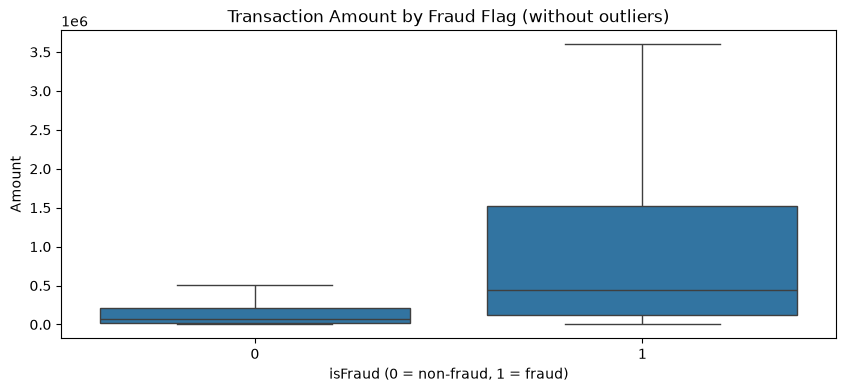

In [36]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='isFraud', y='amount', showfliers=False)
plt.xlabel('isFraud (0 = non-fraud, 1 = fraud)')
plt.ylabel('Amount')
plt.title('Transaction Amount by Fraud Flag (without outliers)')
plt.show()

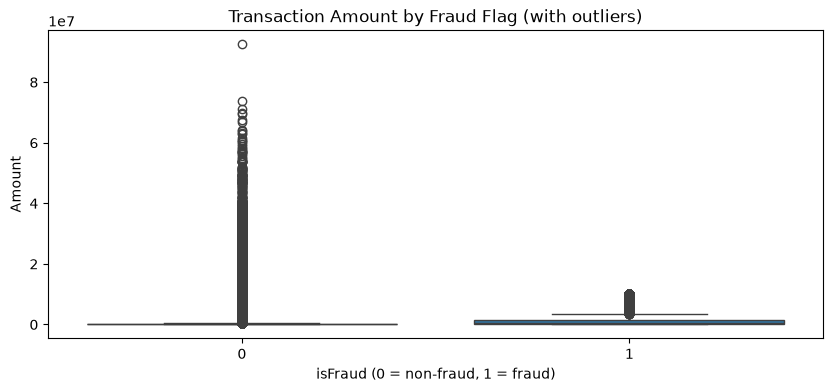

In [37]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='isFraud', y='amount', showfliers=True)
plt.xlabel('isFraud (0 = non-fraud, 1 = fraud)')
plt.ylabel('Amount')
plt.title('Transaction Amount by Fraud Flag (with outliers)')
plt.show()

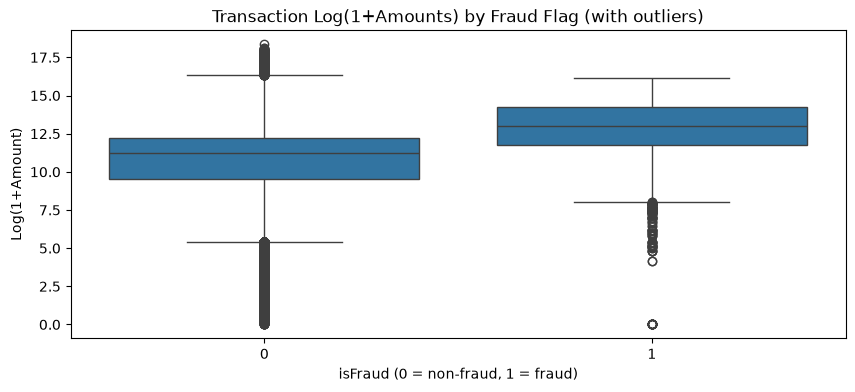

In [53]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='isFraud', y='log1p_amount', showfliers=True)
plt.xlabel('isFraud (0 = non-fraud, 1 = fraud)')
plt.ylabel('Log(1+Amount)')
plt.title('Transaction Log(1+Amounts) by Fraud Flag (with outliers)')
plt.show()

Key takeaways:
- 50% of transactions lie between 10,000 and 210,000 but there is a very big number of outliers falling far beyond 1.5 IQR with some of the outliers amounting to almost 500x of the IQR
- The amount distribution is clearly non-normal and, as revealed by the log(1+p) plots of amounts, it is multi-peaked. 
- The double peak appears to apply to the non-fraudulent transactions, while the fraudulent transactions appear to be centered around a higher mean with fatter tails in the distribution.
- Looking at histogram of log transformed values, the majority of transactions appears to fall between 1800 and 730,000 and they appear to be centered around 13,000 or 270,000 
- fraudulent transactions are centered around a higher amount (~500,000 compared to ~100,000) but the non-fraudulent transations contain many more positive outliers
- Looking at log transformed boxplots, fraudulent transactions appear to be centered around a higher amount with less spread in the data, however there is a significant overlap between fraud and non-fraud amount so this variable alone will probably not be enough to build a model on

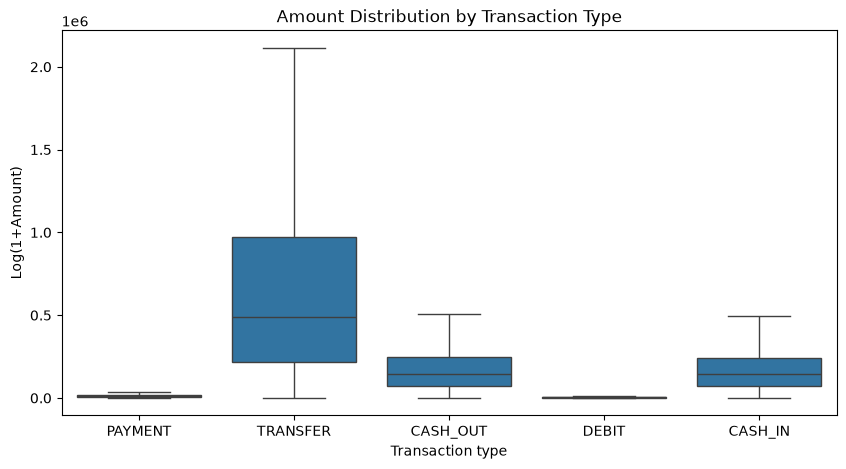

In [60]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='type', y='amount', showfliers=False)
plt.xlabel('Transaction type')
plt.ylabel('Log(1+Amount)')
plt.title('Amount Distribution by Transaction Type')
plt.show()

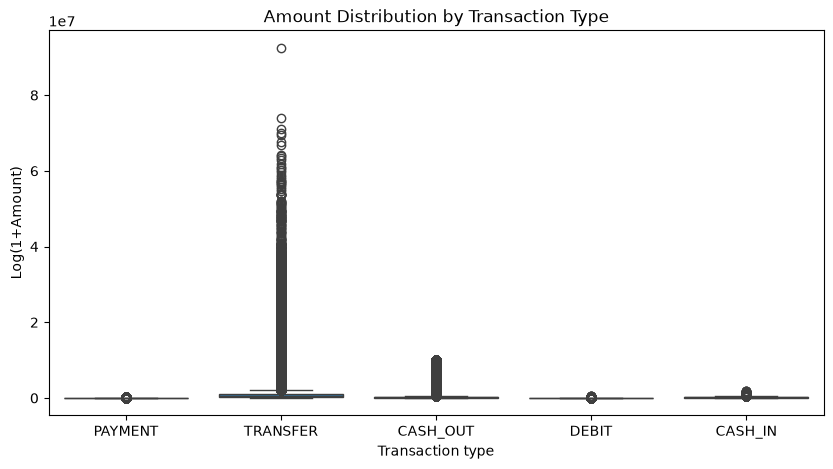

In [62]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='type', y='amount', showfliers=True)
plt.xlabel('Transaction type')
plt.ylabel('Log(1+Amount)')
plt.title('Amount Distribution by Transaction Type')
plt.show()

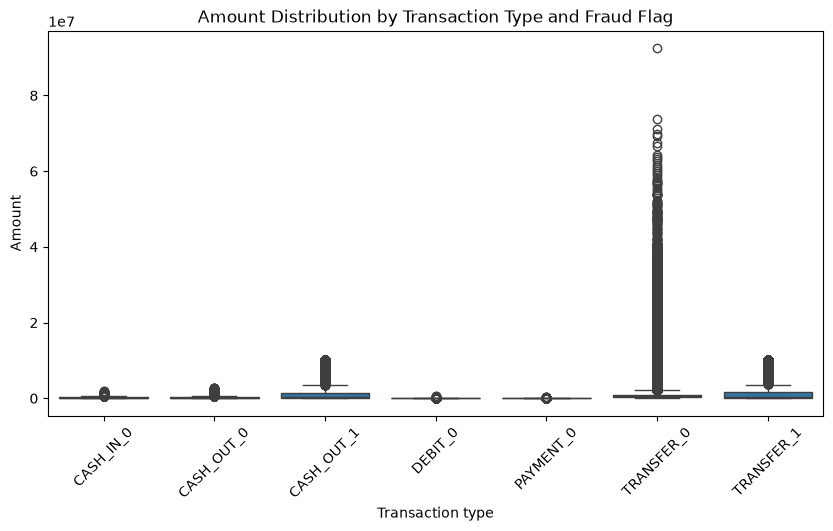

In [67]:
df['type+isFraud'] = df['type'] + '_' + df['isFraud'].astype(str)

df.sort_values(by='type+isFraud', inplace=True)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='type+isFraud', y='amount', showfliers=True)
plt.xticks(rotation=45)
plt.xlabel('Transaction type')
plt.ylabel('Amount')
plt.title('Amount Distribution by Transaction Type and Fraud Flag')
plt.show()

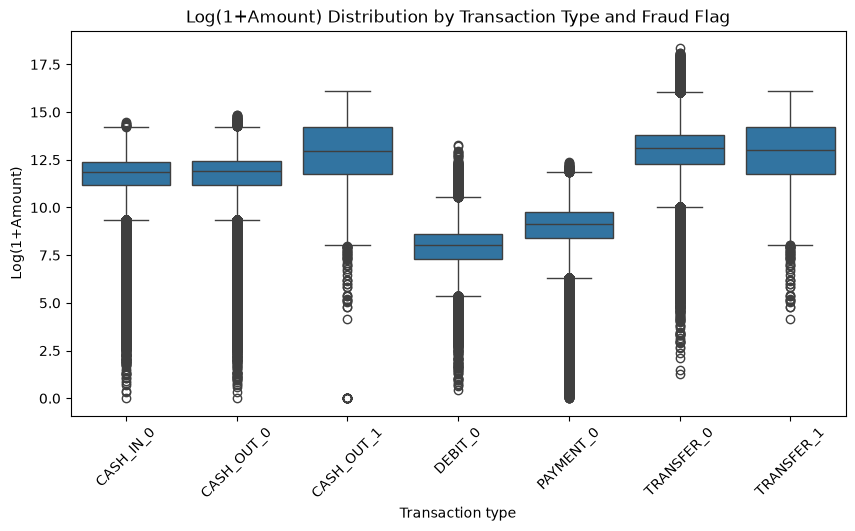

In [66]:
df['type+isFraud'] = df['type'] + '_' + df['isFraud'].astype(str)

df.sort_values(by='type+isFraud', inplace=True)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='type+isFraud', y='log1p_amount', showfliers=True)
plt.xticks(rotation=45)
plt.xlabel('Transaction type')
plt.ylabel('Log(1+Amount)')
plt.title('Log(1+Amount) Distribution by Transaction Type and Fraud Flag')
plt.show()

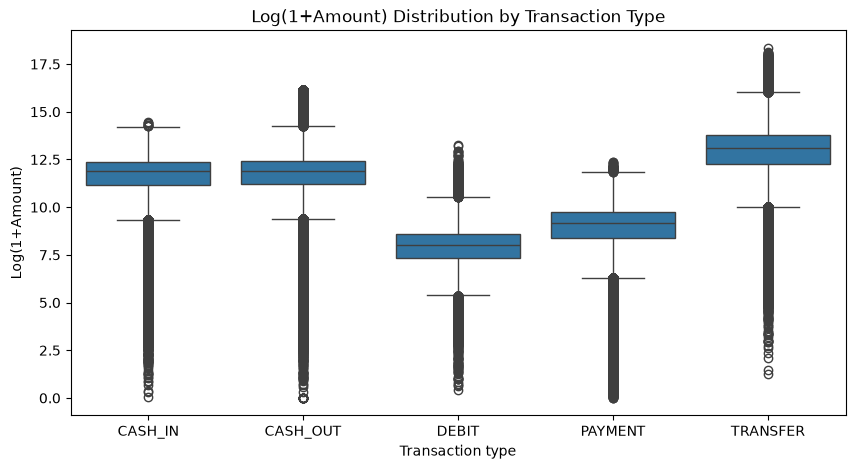

In [68]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='type', y='log1p_amount', showfliers=True)
plt.xlabel('Transaction type')
plt.ylabel('Log(1+Amount)')
plt.title('Log(1+Amount) Distribution by Transaction Type')
plt.show()

Key takeaways:
- there is a clear difference in nature of amounts between different transaction types with 'cash in' and 'cash out' the only types with a similar amounts profile looking at log(1+p) box plots
- 'transfer' type has the highest median 
- spread between amount values is relatively similar between all types
- the highest number of positive outliers can be observed for 'transfer' and 'cash-out'
- some transaction types never apear to be fraudulent: 'payment', 'cash in', 'debit'
- for transactions that can be both fraudulent or not: 'cash out' and 'transfer', there is a difference in amount distributions with some overlap, which is quite big in the case of 'transfer' transactions
- the fraudulent 'cash out' transactions are centered around higher values and have more variability within the center of the distribution as well as within the entire distribution (excluding the outliers)
- the fraudulent 'transfer' transactions are centered around an amount almost equal to that of non-fraudulent transfers but they have much more variability in the amounts distribution
- the highest amount outliers are not fraudulent
- in general the amount values between fraud and non-fraud are often overlapping which might make it hard for the model to predict the fraud using amounts and transaction types only

## Potential data quality issues

- Data leakage in the 'balance new' type of variables, there should not be used for modelling
- According to the dataset creators, due to the nature of the simulation, all features related to accounts balances should not be used for modelling, I'm going to follow their advice for the final model, however I will perform some tests building models including them as well
- due to a high cardinality of the client names no aggregate client-level features can potentially be engineered as features

## Takeaways for feature creation

- amount (or log(1+amount)) should be used for sure
- transaction type seems to carry additional discriminative power for fraud label
- don't use 'isFlaggedFraud' as we want to create a more sophisticated model
- variable around isMerchant for the receiver of a transaction
- try to convert step to incorporate day and week cyclicality
- aggregate transaction receiver characteristics could potentially be added to the model but not for sender - almost no repeating IDs